In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('supply_chain_data.csv')

In [4]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [5]:
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    str    
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    str    
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    str    
 14  Location                 100 non-null 

In [7]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [8]:
df.shape

(100, 24)

In [9]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [12]:
df.columns

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'lead_times', 'order_quantities', 'shipping_times',
       'shipping_carriers', 'shipping_costs', 'supplier_name', 'location',
       'lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'inspection_results', 'defect_rates',
       'transportation_modes', 'routes', 'costs'],
      dtype='str')

In [13]:
df.groupby('product_type')['revenue_generated'].sum().sort_values(ascending=False)

product_type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: revenue_generated, dtype: float64

In [14]:
df.groupby('transportation_modes')['shipping_costs'].mean()

transportation_modes
Air     6.017839
Rail    5.469098
Road    5.542115
Sea     4.970294
Name: shipping_costs, dtype: float64

In [15]:
df.groupby('supplier_name')['defect_rates'].mean().sort_values(ascending=False)

supplier_name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: defect_rates, dtype: float64

In [16]:
df[['sku','product_type','stock_levels']].sort_values(by='stock_levels')

,sku,product_type,stock_levels
68,SKU68,haircare,0
2,SKU2,haircare,1
34,SKU34,skincare,1
16,SKU16,skincare,2
24,SKU24,haircare,4
...,...,...,...
49,SKU49,cosmetics,97
91,SKU91,cosmetics,98
59,SKU59,cosmetics,100
12,SKU12,haircare,100


In [17]:
df[['sku','product_type','stock_levels','number_of_products_sold','revenue_generated']].sort_values(by='stock_levels')


,sku,product_type,stock_levels,number_of_products_sold,revenue_generated
68,SKU68,haircare,0,163,3550.218433
2,SKU2,haircare,1,8,9577.749626
34,SKU34,skincare,1,602,9061.710896
16,SKU16,skincare,2,280,6453.797968
24,SKU24,haircare,4,209,9049.077861
...,...,...,...,...,...
49,SKU49,cosmetics,97,99,8001.613207
91,SKU91,cosmetics,98,916,1935.206794
59,SKU59,cosmetics,100,484,1061.618523
12,SKU12,haircare,100,336,2873.741446


In [18]:
def inventory_status(row):
    
    if row['stock_levels'] < 10 and row['number_of_products_sold'] > 500:
        return 'Critical Stock Risk'
    
    elif row['stock_levels'] > 80 and row['number_of_products_sold'] < 200:
        return 'Overstock Risk'
    
    else:
        return 'Normal'

df['inventory_status'] = df.apply(inventory_status, axis=1)

df[['sku','product_type','stock_levels',
    'number_of_products_sold',
    'inventory_status']].head(20)

,sku,product_type,stock_levels,number_of_products_sold,inventory_status
0,SKU0,haircare,58,802,Normal
1,SKU1,skincare,53,736,Normal
2,SKU2,haircare,1,8,Normal
3,SKU3,skincare,23,83,Normal
4,SKU4,skincare,5,871,Critical Stock Risk
5,SKU5,haircare,90,147,Overstock Risk
6,SKU6,skincare,11,65,Normal
7,SKU7,cosmetics,93,426,Normal
8,SKU8,cosmetics,5,150,Normal
9,SKU9,skincare,14,980,Normal


In [19]:
df['inventory_status'].value_counts()


inventory_status
Normal                 89
Overstock Risk          6
Critical Stock Risk     5
Name: count, dtype: int64

In [20]:
df[df['inventory_status'] == 'Critical Stock Risk']

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs,inventory_status
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,Critical Stock Risk
33,cosmetics,SKU33,64.795435,63,616,5149.998350,Non-binary,4,17,95,...,1,251,23,23.853428,Fail,3.541046,Sea,Route A,371.255296,Critical Stock Risk
34,skincare,SKU34,37.467592,96,602,9061.710896,Unknown,1,26,21,...,4,452,10,10.754273,Pass,0.646605,Road,Route B,510.358000,Critical Stock Risk
47,skincare,SKU47,95.712136,93,910,7089.474250,Male,4,15,51,...,10,964,20,19.712993,Pending,0.380574,Rail,Route A,581.602355,Critical Stock Risk
78,haircare,SKU78,6.306883,50,946,1292.458418,Unknown,5,4,51,...,25,858,21,71.126515,Pending,4.096881,Sea,Route C,323.592203,Critical Stock Risk


In [21]:
df[df['inventory_status'] == 'Overstock Risk']

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs,inventory_status
5,haircare,SKU5,1.699976,87,147,2828.348746,Non-binary,90,27,66,...,10,104,17,56.766476,Fail,2.779194,Road,Route A,235.461237,Overstock Risk
25,haircare,SKU25,39.629344,73,142,2174.777054,Male,82,11,52,...,19,934,23,78.280383,Pending,3.797231,Road,Route B,458.535946,Overstock Risk
45,haircare,SKU45,33.784138,1,24,5267.956808,Male,93,7,52,...,25,794,25,66.312544,Pass,3.219605,Rail,Route A,495.305697,Overstock Risk
49,cosmetics,SKU49,78.897913,19,99,8001.613207,Unknown,97,24,9,...,28,177,28,14.147815,Pass,2.825814,Rail,Route A,336.890169,Overstock Risk
51,haircare,SKU51,26.700761,61,154,9866.465458,Male,100,4,52,...,18,673,28,14.190328,Pending,1.772951,Road,Route A,694.982318,Overstock Risk
89,cosmetics,SKU89,97.760086,10,134,5924.682567,Unknown,90,1,27,...,23,370,11,46.603873,Pending,1.907666,Rail,Route B,517.499974,Overstock Risk


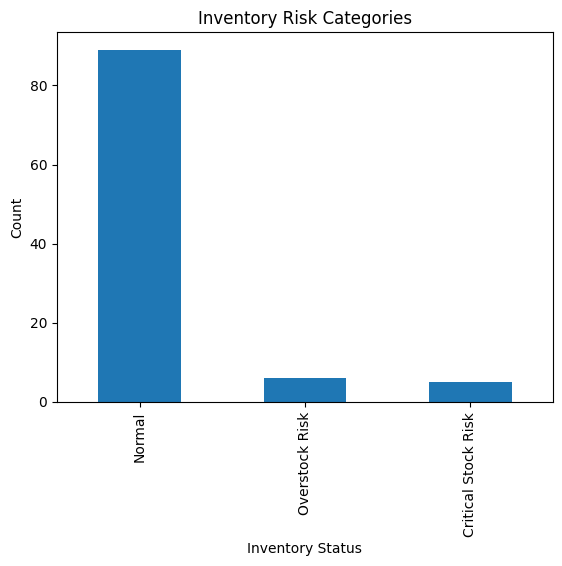

In [22]:
df['inventory_status'].value_counts().plot(kind='bar')

plt.title('Inventory Risk Categories')
plt.xlabel('Inventory Status')
plt.ylabel('Count')
plt.show()

In [23]:
df.groupby('supplier_name')['defect_rates'].mean().sort_values(ascending=False)

supplier_name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: defect_rates, dtype: float64

## Supplier 5 exhibited the highest average defect rate, indicating potential quality control inefficiencies and increased operational risk within the supply chain.

In [24]:
def supplier_risk(defect_rate):
    
    if defect_rate > 2.5:
        return 'High Risk'
    
    elif defect_rate > 2:
        return 'Medium Risk'
    
    else:
        return 'Low Risk'

supplier_risk_df = df.groupby('supplier_name')['defect_rates'].mean().reset_index()

supplier_risk_df['risk_level'] = supplier_risk_df['defect_rates'].apply(supplier_risk)

supplier_risk_df

,supplier_name,defect_rates,risk_level
0,Supplier 1,1.803630,Low Risk
1,Supplier 2,2.362750,Medium Risk
2,Supplier 3,2.465786,Medium Risk
3,Supplier 4,2.337397,Medium Risk
4,Supplier 5,2.665408,High Risk


In [25]:
df.groupby('transportation_modes')['shipping_times'].mean().sort_values()

transportation_modes
Road    4.724138
Air     5.115385
Rail    6.571429
Sea     7.117647
Name: shipping_times, dtype: float64

In [26]:
df.groupby('transportation_modes')[['shipping_costs','shipping_times']].mean()

,shipping_costs,shipping_times
transportation_modes,,
Air,6.017839,5.115385
Rail,5.469098,6.571429
Road,5.542115,4.724138
Sea,4.970294,7.117647


In [27]:
df[['routes','transportation_modes','shipping_costs']].sort_values(by='shipping_costs', ascending=False)

,routes,transportation_modes,shipping_costs
89,Route B,Rail,9.929816
28,Route A,Air,9.898141
24,Route A,Air,9.741292
1,Route B,Road,9.716575
69,Route A,Air,9.705287
...,...,...,...
12,Route B,Road,1.325274
99,Route B,Rail,1.311024
68,Route A,Rail,1.194252
34,Route B,Road,1.019488


In [28]:
def shipping_efficiency(row):
    
    if row['shipping_costs'] > 8 and row['shipping_times'] > 5:
        return 'Inefficient'
    
    elif row['shipping_costs'] < 5 and row['shipping_times'] < 3:
        return 'Efficient'
    
    else:
        return 'Moderate'

df['shipping_efficiency'] = df.apply(shipping_efficiency, axis=1)

df[['transportation_modes',
    'shipping_costs',
    'shipping_times',
    'shipping_efficiency']].head()

,transportation_modes,shipping_costs,shipping_times,shipping_efficiency
0,Road,2.956572,4,Moderate
1,Road,9.716575,2,Moderate
2,Air,8.054479,2,Moderate
3,Rail,1.729569,6,Moderate
4,Air,3.890548,8,Moderate


In [29]:
df['shipping_efficiency'].value_counts()

shipping_efficiency
Moderate       81
Inefficient    13
Efficient       6
Name: count, dtype: int64

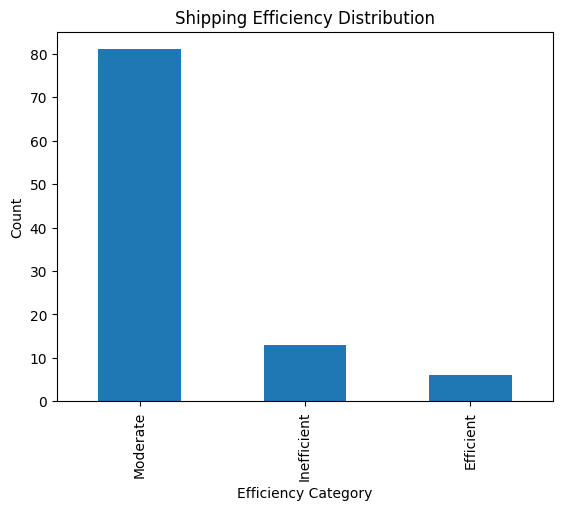

In [30]:
df['shipping_efficiency'].value_counts().plot(kind='bar')

plt.title('Shipping Efficiency Distribution')
plt.xlabel('Efficiency Category')
plt.ylabel('Count')
plt.show()

In [31]:
df.groupby('supplier_name')['defect_rates'].mean().sort_values(ascending=False)

supplier_name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: defect_rates, dtype: float64

## Supplier 5 exhibited the highest average defect rate, indicating potential quality control inefficiencies and increased operational risk within the supply chain

In [32]:
def supplier_risk(defect_rate):
    
    if defect_rate > 2.5:
        return 'High Risk'
    
    elif defect_rate > 2:
        return 'Medium Risk'
    
    else:
        return 'Low Risk'

supplier_risk_df = df.groupby('supplier_name')['defect_rates'].mean().reset_index()

supplier_risk_df['risk_level'] = supplier_risk_df['defect_rates'].apply(supplier_risk)

supplier_risk_df

,supplier_name,defect_rates,risk_level
0,Supplier 1,1.803630,Low Risk
1,Supplier 2,2.362750,Medium Risk
2,Supplier 3,2.465786,Medium Risk
3,Supplier 4,2.337397,Medium Risk
4,Supplier 5,2.665408,High Risk


In [33]:
df.groupby('transportation_modes')['shipping_times'].mean().sort_values()

transportation_modes
Road    4.724138
Air     5.115385
Rail    6.571429
Sea     7.117647
Name: shipping_times, dtype: float64

In [34]:
df[['routes','transportation_modes','shipping_costs']].sort_values(by='shipping_costs', ascending=False)

,routes,transportation_modes,shipping_costs
89,Route B,Rail,9.929816
28,Route A,Air,9.898141
24,Route A,Air,9.741292
1,Route B,Road,9.716575
69,Route A,Air,9.705287
...,...,...,...
12,Route B,Road,1.325274
99,Route B,Rail,1.311024
68,Route A,Rail,1.194252
34,Route B,Road,1.019488


In [35]:
def shipping_efficiency(row):
    
    if row['shipping_costs'] > 8 and row['shipping_times'] > 5:
        return 'Inefficient'
    
    elif row['shipping_costs'] < 5 and row['shipping_times'] < 3:
        return 'Efficient'
    
    else:
        return 'Moderate'

df['shipping_efficiency'] = df.apply(shipping_efficiency, axis=1)

df[['transportation_modes',
    'shipping_costs',
    'shipping_times',
    'shipping_efficiency']].head()

,transportation_modes,shipping_costs,shipping_times,shipping_efficiency
0,Road,2.956572,4,Moderate
1,Road,9.716575,2,Moderate
2,Air,8.054479,2,Moderate
3,Rail,1.729569,6,Moderate
4,Air,3.890548,8,Moderate


In [36]:
df['shipping_efficiency'].value_counts()

shipping_efficiency
Moderate       81
Inefficient    13
Efficient       6
Name: count, dtype: int64

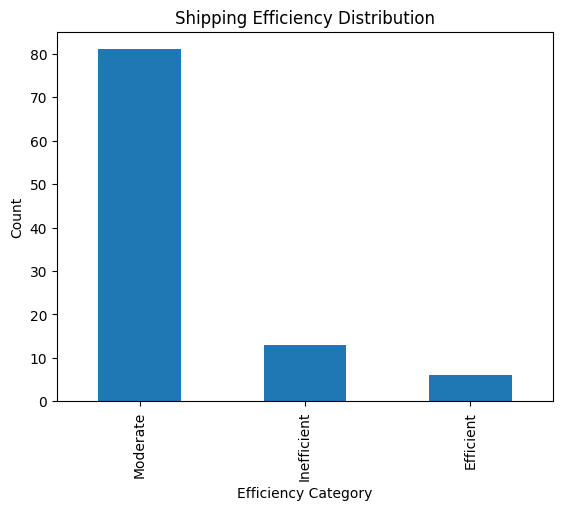

In [37]:
df['shipping_efficiency'].value_counts().plot(kind='bar')

plt.title('Shipping Efficiency Distribution')
plt.xlabel('Efficiency Category')
plt.ylabel('Count')
plt.show()

In [38]:
numerical_df = df.select_dtypes(include=['int64','float64'])

numerical_df.head()

,price,availability,number_of_products_sold,revenue_generated,stock_levels,lead_times,order_quantities,shipping_times,shipping_costs,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,defect_rates,costs
0,69.808006,55,802,8661.996792,58,7,96,4,2.956572,29,215,29,46.279879,0.226410,187.752075
1,14.843523,95,736,7460.900065,53,30,37,2,9.716575,23,517,30,33.616769,4.854068,503.065579
2,11.319683,34,8,9577.749626,1,10,88,2,8.054479,12,971,27,30.688019,4.580593,141.920282
3,61.163343,68,83,7766.836426,23,13,59,6,1.729569,24,937,18,35.624741,4.746649,254.776159
4,4.805496,26,871,2686.505152,5,3,56,8,3.890548,5,414,3,92.065161,3.145580,923.440632


In [39]:
correlation_matrix = numerical_df.corr()

correlation_matrix

,price,availability,number_of_products_sold,revenue_generated,stock_levels,lead_times,order_quantities,shipping_times,shipping_costs,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,defect_rates,costs
price,1.000000,0.019083,0.005739,0.038424,0.078261,0.044855,0.095819,0.071942,0.058543,0.152185,-0.124575,-0.301313,-0.184123,-0.147247,0.088501
availability,0.019083,1.000000,0.087496,-0.075170,-0.025900,0.170439,0.143769,-0.051377,-0.044179,-0.156669,0.050134,0.065333,0.134652,0.040626,-0.027315
number_of_products_sold,0.005739,0.087496,1.000000,-0.001641,0.022189,-0.046419,0.015992,0.087315,0.044285,0.041230,0.187945,-0.048939,0.034284,-0.082726,-0.036951
revenue_generated,0.038424,-0.075170,-0.001641,1.000000,-0.158480,-0.057296,0.029422,-0.109211,-0.072892,-0.014178,-0.037441,0.014073,-0.214025,-0.125335,0.027252
stock_levels,0.078261,-0.025900,0.022189,-0.158480,1.000000,0.072571,-0.111455,-0.094883,0.072907,0.067880,0.043763,-0.050592,0.033243,-0.149478,-0.012088
lead_times,0.044855,0.170439,-0.046419,-0.057296,0.072571,1.000000,0.105459,-0.045156,-0.120746,-0.002818,-0.145324,0.003364,-0.024441,0.015681,0.243686
order_quantities,0.095819,0.143769,0.015992,0.029422,-0.111455,0.105459,1.000000,-0.002561,0.004261,-0.086189,-0.086567,0.112347,-0.026784,0.018986,0.167306
shipping_times,0.071942,-0.051377,0.087315,-0.109211,-0.094883,-0.045156,-0.002561,1.000000,0.045108,-0.022214,-0.060470,-0.016953,0.029132,-0.036673,-0.045541
shipping_costs,0.058543,-0.044179,0.044285,-0.072892,0.072907,-0.120746,0.004261,0.045108,1.000000,0.029680,-0.097979,-0.005653,0.005984,0.083139,0.051671
lead_time,0.152185,-0.156669,0.041230,-0.014178,0.067880,-0.002818,-0.086189,-0.022214,0.029680,1.000000,0.212676,0.026756,-0.121999,0.297099,0.045219


In [40]:
correlation_matrix['revenue_generated'].sort_values(ascending=False)

revenue_generated          1.000000
price                      0.038424
order_quantities           0.029422
costs                      0.027252
manufacturing_lead_time    0.014073
number_of_products_sold   -0.001641
lead_time                 -0.014178
production_volumes        -0.037441
lead_times                -0.057296
shipping_costs            -0.072892
availability              -0.075170
shipping_times            -0.109211
defect_rates              -0.125335
stock_levels              -0.158480
manufacturing_costs       -0.214025
Name: revenue_generated, dtype: float64

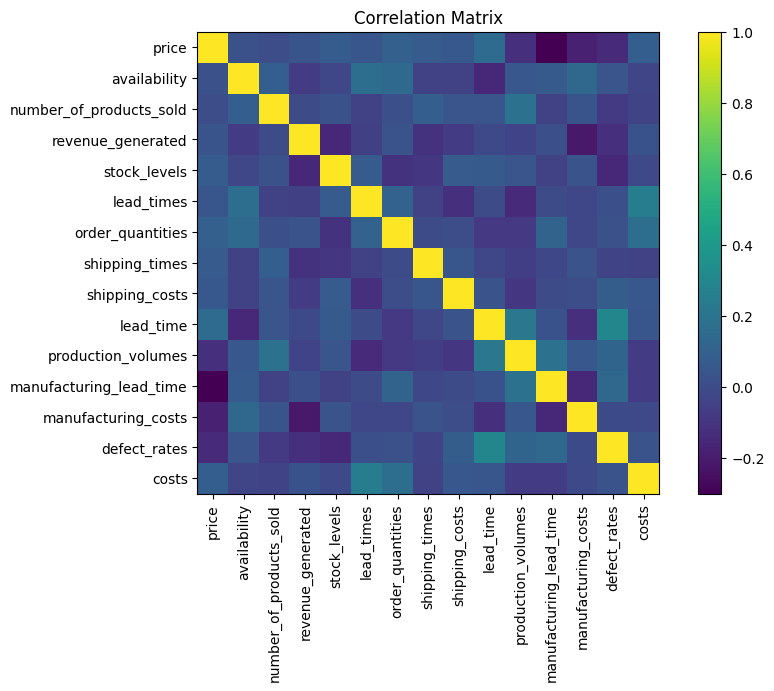

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=90)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title('Correlation Matrix')

plt.show()

## Inventory Insight

Overstocked products tend to generate lower revenue, indicating inefficient inventory utilization.

## Quality Insight

Higher defect rates negatively impact revenue generation, suggesting quality issues affect business performance.

## Logistics Insight

Longer shipping times show slight negative impact on revenue, highlighting importance of faster delivery.

## Manufacturing Insight

Increased manufacturing costs are associated with lower revenue efficiency.

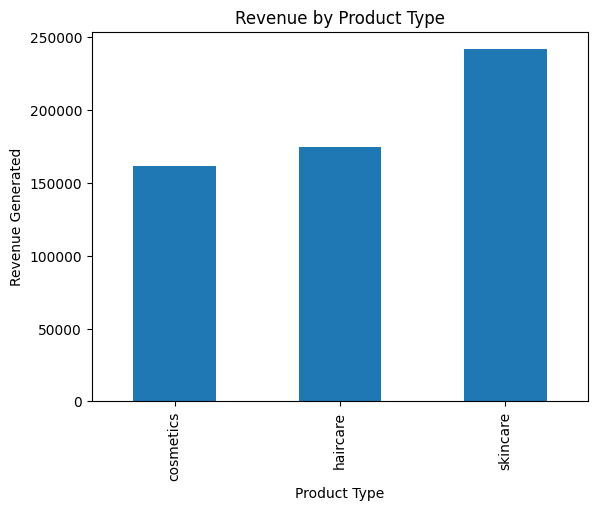

In [42]:
revenue_by_product = df.groupby('product_type')['revenue_generated'].sum()

revenue_by_product.plot(kind='bar')

plt.title('Revenue by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Revenue Generated')

plt.show()

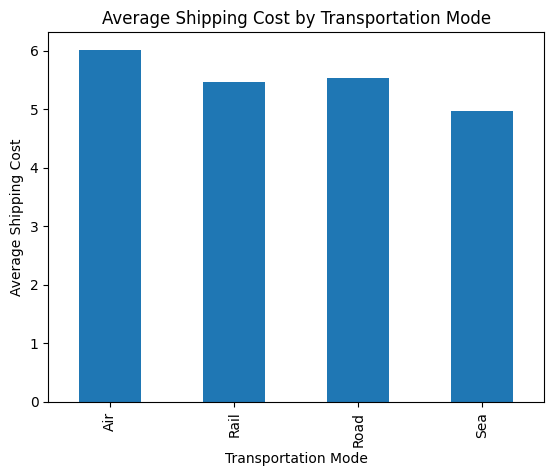

In [43]:
shipping_costs = df.groupby('transportation_modes')['shipping_costs'].mean()

shipping_costs.plot(kind='bar')

plt.title('Average Shipping Cost by Transportation Mode')
plt.xlabel('Transportation Mode')
plt.ylabel('Average Shipping Cost')

plt.show()

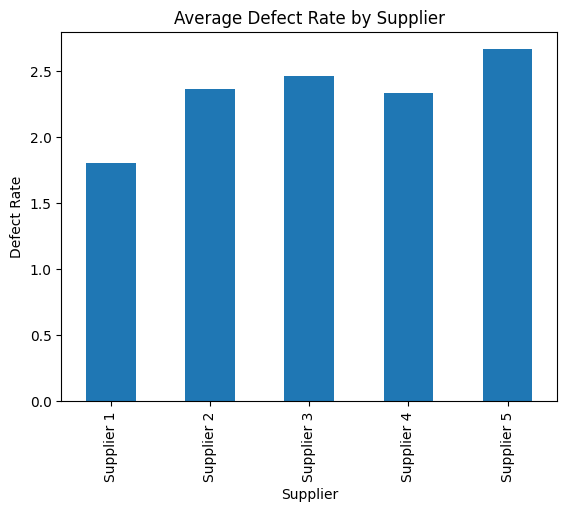

In [44]:
supplier_defects = df.groupby('supplier_name')['defect_rates'].mean()

supplier_defects.plot(kind='bar')

plt.title('Average Defect Rate by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Defect Rate')

plt.show()

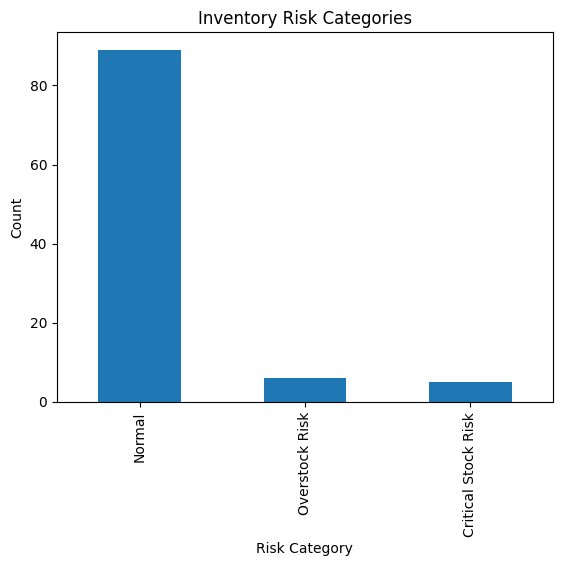

In [45]:
df['inventory_status'].value_counts().plot(kind='bar')

plt.title('Inventory Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Count')

plt.show()

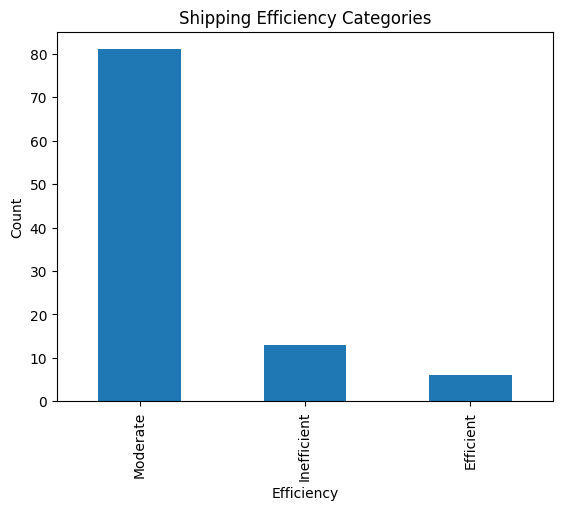

In [46]:
df['shipping_efficiency'].value_counts().plot(kind='bar')

plt.title('Shipping Efficiency Categories')
plt.xlabel('Efficiency')
plt.ylabel('Count')

plt.show()

In [47]:
df.to_csv("cleaned_supply_chain_data.csv", index=False)